# Conditional Lag-CRP

> Compute and visualize lag-conditional response probability with transition filtering.

The conditional Lag-CRP extends the standard Lag-CRP by adding a `_should_tabulate` mask that controls which transitions are counted. When `_should_tabulate[i]` is False for a recall event, the tabulator still updates internal state (availability, previous positions) but does **not** increment actual or available lag tallies for that transition.

$$\text{CRP}(\ell) = \frac{\text{actual transitions at lag } \ell}{\text{available transitions at lag } \ell}$$

This is useful for analyses that need to exclude specific transitions (e.g., cued recalls, intrusions) while preserving correct availability tracking across the full recall sequence.

This notebook is parameterized for use with [papermill](https://papermill.readthedocs.io/).

| Parameter | Description |
|-----------|-------------|
| `run_tag` | Label for this analysis run |
| `data_path` | Path to HDF5 dataset file |
| `figure_dir` | Directory for saving figures |
| `figure_str` | Filename for saved figure (empty string to skip saving) |
| `ylim` | Y-axis limits as tuple, or `None` for auto |
| `trial_query` | Query string for trial selection |

: Notebook parameters {#tbl-parameters}

In [1]:
#| include: false
from nbdev.showdoc import show_doc

In [2]:
#| code-summary: Imports and setup
import os
import warnings

import jax.numpy as jnp
import matplotlib.pyplot as plt

from jaxcmr.analyses.conditional_crp import (
    crp,
    plot_crp,
    set_false_at_index,
    Tabulation,
    tabulate_trial,
)
from jaxcmr.helpers import find_project_root, generate_trial_mask, load_data

warnings.filterwarnings("ignore")


def save_figure(figure_dir, figure_str, suffix=None):
    plt.tight_layout()
    if not figure_str:
        plt.show()
        return
    os.makedirs(figure_dir, exist_ok=True)
    suffix_str = f"_{suffix}" if suffix else ""
    figure_path = os.path.join(figure_dir, f"{figure_str}{suffix_str}.png")
    plt.savefig(figure_path, bbox_inches="tight", dpi=600)
    plt.show()

In [3]:
#| code-summary: Parameters for this analysis

run_tag = "conditional_crp"
data_path = "data/HealeyKahana2014.h5"
figure_dir = "results/figures"
figure_str = ""
ylim = None
trial_query = "data['listtype'] == -1"

In [4]:
#| code-summary: Load data and construct _should_tabulate mask
project_root = find_project_root()
figure_dir = os.path.join(project_root, figure_dir)
data_path = os.path.join(project_root, data_path)
data = load_data(data_path)
trial_mask = generate_trial_mask(data, trial_query)

# Construct _should_tabulate: tabulate all valid recalls
should_tabulate = data["recalls"] > 0
data_with_mask = {**data, "_should_tabulate": should_tabulate}

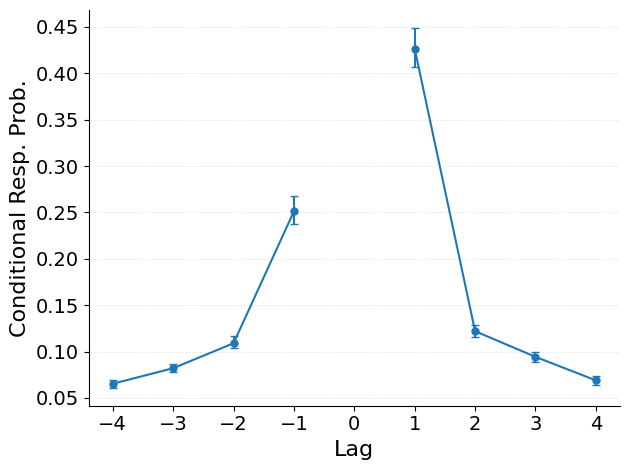

In [5]:
#| code-summary: Plot Conditional Lag-CRP
#| label: fig-conditional-crp
#| fig-cap: "Conditional Lag-CRP showing response probability by serial lag."
plot_crp(data_with_mask, trial_mask)
if ylim is not None:
    for ax in plt.gcf().axes:
        ax.set_ylim(ylim)
save_figure(figure_dir, figure_str)

---

## Reference

In [6]:
#| echo: false
show_doc(plot_crp)

---

### plot_crp

>      plot_crp (datasets:Union[Sequence[jaxcmr.typing.RecallDataset],jaxcmr.typ
>                ing.RecallDataset], trial_masks:Union[Sequence[jaxtyping.Bool[A
>                rray,'trial_count']],jaxtyping.Bool[Array,'trial_count']],
>                max_lag:int=4, color_cycle:Optional[list[str]]=None,
>                labels:Optional[Sequence[str]]=None,
>                contrast_name:Optional[str]=None,
>                axis:Optional[matplotlib.axes._axes.Axes]=None, size:int=3,
>                confidence_level:float=0.95)

*Plot subject-wise conditional Lag-CRP with error bounds.*

|    | **Type** | **Default** | **Details** |
| -- | -------- | ----------- | ----------- |
| datasets | Union |  | Datasets containing trial data to plot. |
| trial_masks | Union |  | Masks to filter trials in datasets. |
| max_lag | int | 4 | Maximum lag to plot. |
| color_cycle | Optional | None | Colors for plotting each dataset. |
| labels | Optional | None | Legend labels for each dataset. |
| contrast_name | Optional | None | Legend title for contrasts. |
| axis | Optional | None | Existing matplotlib Axes to plot on. |
| size | int | 3 | Max study positions an item can occupy. |
| confidence_level | float | 0.95 | Confidence level for the bounds. |
| **Returns** | **Axes** |  | **Matplotlib Axes with the Lag-CRP plot.** |

In [7]:
# plot_crp returns an Axes object
from matplotlib.axes import Axes

ax = plot_crp(data_with_mask, trial_mask)
assert isinstance(ax, Axes)
plt.close()

In [8]:
#| echo: false
show_doc(crp)

---

### crp

>      crp (dataset:jaxcmr.typing.RecallDataset, size:int=3)

*Compute conditional Lag-CRP with repeated items.*

|    | **Type** | **Default** | **Details** |
| -- | -------- | ----------- | ----------- |
| dataset | RecallDataset |  | Dataset with ``recalls``, ``pres_itemnos``, and<br>``_should_tabulate``. |
| size | int | 3 | Max study positions an item can occupy. |
| **Returns** | **Float[Array, 'lags']** |  | **CRP of length 2*L - 1; NaN where denominator is zero.** |

In [9]:
# crp returns a 1-D array of length 2*L - 1
trials = jnp.array([[2, 3, 4, 0]], dtype=jnp.int32)
presentations = jnp.array([[1, 2, 3, 4]], dtype=jnp.int32)
should_tab = jnp.array([[True, True, True, False]], dtype=bool)

dataset = {
    "subject": jnp.ones((1, 1), dtype=jnp.int32),
    "listLength": jnp.full((1, 1), 4, dtype=jnp.int32),
    "pres_itemnos": presentations,
    "recalls": trials,
    "_should_tabulate": should_tab,
}

result = crp(dataset, size=1)
assert result.shape == (7,)  # 2 * 4 - 1 = 7

In [10]:
#| echo: false
show_doc(tabulate_trial)

---

### tabulate_trial

>      tabulate_trial (trial:jaxtyping.Integer[Array,'recall_events'],
>                      presentation:jaxtyping.Integer[Array,'study_events'],
>                      should_tabulate:jaxtyping.Bool[Array,'recall_events'],
>                      size:int=3)

*Tabulate actual and available lags for a single trial.*

|    | **Type** | **Default** | **Details** |
| -- | -------- | ----------- | ----------- |
| trial | Integer[Array, 'recall_events'] |  | Recall sequence as within-list positions. |
| presentation | Integer[Array, 'study_events'] |  | Study presentation order for the trial. |
| should_tabulate | Bool[Array, 'recall_events'] |  | Boolean mask; True counts the transition. |
| size | int | 3 | Max study positions an item can occupy. |
| **Returns** | **tuple** |  | **Actual and available lag counts.** |

In [11]:
# tabulate_trial returns a pair of lag arrays
trial = jnp.array([1, 2, 3], dtype=jnp.int32)
presentation = jnp.array([1, 2, 3], dtype=jnp.int32)
mask = jnp.array([True, True, True], dtype=bool)

actual, avail = tabulate_trial(trial, presentation, mask, size=1)
assert actual.shape == (5,)  # 2 * 3 - 1 = 5
assert avail.shape == (5,)

In [12]:
#| echo: false
show_doc(set_false_at_index)

---

### set_false_at_index

>      set_false_at_index (vec:jaxtyping.Bool[Array,'positions'],
>                          i:jaxtyping.Integer[Array,'']|int)

*Set ``vec[i - 1]`` to ``False`` using 1-based indexing.*

|    | **Type** | **Details** |
| -- | -------- | ----------- |
| vec | Bool[Array, 'positions'] | Boolean availability vector. |
| i | jaxtyping.Integer[Array, ''] \| int | 1-based index to clear; ``0`` is a no-op sentinel. |
| **Returns** | **tuple** | **Updated vector and ``None``.** |

In [13]:
# 1-based indexing: index 3 clears position 2 (0-based)
vec = jnp.array([True, True, True, True], dtype=bool)
updated, _ = set_false_at_index(vec, 3)
assert updated.tolist() == [True, True, False, True]

# Index 0 is a no-op sentinel
unchanged, _ = set_false_at_index(vec, 0)
assert unchanged.tolist() == [True, True, True, True]